# 08 — Model Comparison & Specification Sensitivity

**Purpose:** Compare all 5 models side-by-side and analyse why they produce different results using the Structured Specification Testing framework.

**Models compared:**
1. TF-IDF + LogReg (notebook 03)
2. Sentence Transformer + LogReg + metadata (notebook 04)
3. Fine-tuned DistilBERT (notebook 05)
4. Claude Zero-Shot (notebook 06)
5. Claude Few-Shot (notebook 06)

**Analyses:**
- Side-by-side comparison (Macro F1, Top-1, Top-2)
- Per-class F1 variance (specification sensitivity)
- Top-2 per-class comparison
- False positive analysis for best model
- Label consistency check (ground truth reliability)
- Calibration comparison
- Proxy concentration analysis (construct vs proxy features)
- Normative divergence (Claude vs ST disagreement direction)
- Frame sensitivity (DSPy vs hand-crafted prompt)

**Final model:** Sentence Transformer + metadata (0.765 macro F1, 91.6% top-2). Chosen in notebook 07 after hybrid testing showed no improvement.


# 0. Imports & Load Results

In [6]:
import pandas as pd
import numpy as np
import json
import joblib
from pathlib import Path

from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

%matplotlib inline

In [7]:
DATA_DIR = Path("../data/modelling")
MODEL_DIR = Path("../models")

# Load val data
val_df = pd.read_csv(DATA_DIR / "val.csv")
train_df = pd.read_csv(DATA_DIR / "train.csv")
y_val = val_df["target"]
label_names = sorted(val_df["target"].unique())

with open(DATA_DIR / "metadata_columns.json") as f:
    metadata_cols = json.load(f)

print(f"Val: {len(val_df)} rows, {len(label_names)} classes")

Val: 167 rows, 6 classes


In [8]:
# Load trained models
tfidf_vec = joblib.load(MODEL_DIR / "baseline_tfidf.joblib")
tfidf_clf = joblib.load(MODEL_DIR / "baseline_logreg.joblib")
sbert_clf = joblib.load(MODEL_DIR / "sbert_classifier.joblib")
sbert_emb_val = np.load(MODEL_DIR / "sbert_val_embeddings.npy")

# Load Claude predictions
claude_zero_df = pd.read_csv(DATA_DIR / "claude_zero_shot_predictions.csv")
claude_few_df = pd.read_csv(DATA_DIR / "claude_few_shot_predictions.csv")

print("All models loaded.")

All models loaded.


In [9]:
# Generate predictions for trained models
# TF-IDF
X_val_tfidf = tfidf_vec.transform(val_df["text_clean"])
tfidf_pred = tfidf_clf.predict(X_val_tfidf)
tfidf_proba = tfidf_clf.predict_proba(X_val_tfidf)

# Sentence Transformer + metadata
X_val_sbert = np.hstack([sbert_emb_val, val_df[metadata_cols].values])
sbert_pred = sbert_clf.predict(X_val_sbert)
sbert_proba = sbert_clf.predict_proba(X_val_sbert)
sbert_classes = sbert_clf.classes_

print("Predictions generated.")

Predictions generated.


# 1. Side-by-side comparison

In [10]:
# Macro F1 and Top-2 for all models
results = {}

# TF-IDF
results["TF-IDF + LogReg"] = {
    "f1": f1_score(y_val, tfidf_pred, average="macro"),
    "top2": np.mean([
        np.where(tfidf_clf.classes_ == true)[0][0] in np.argsort(tfidf_proba[i])[-2:]
        for i, true in enumerate(y_val)
    ]),
}

# Sentence Transformer
results["Sent. Transformer + meta"] = {
    "f1": f1_score(y_val, sbert_pred, average="macro"),
    "top2": np.mean([
        np.where(sbert_classes == true)[0][0] in np.argsort(sbert_proba[i])[-2:]
        for i, true in enumerate(y_val)
    ]),
}

# DistilBERT — hardcoded from notebook 05 (CSV will be saved when notebook 05 is rerun)
# TODO: replace with pd.read_csv(DATA_DIR / "distilbert_predictions.csv") after rerunning notebook 05
results["Fine-tuned DistilBERT"] = {
    "f1": 0.750,
    "top2": 0.886,
}

# Claude Zero-Shot
valid_zero = claude_zero_df[claude_zero_df["category"].isin(label_names)]
results["Claude Zero-Shot"] = {
    "f1": f1_score(valid_zero["true_label"], valid_zero["category"], average="macro"),
    "top2": ((valid_zero["category"] == valid_zero["true_label"]) | 
             (valid_zero["second_category"] == valid_zero["true_label"])).mean(),
}

# Claude Few-Shot
valid_few = claude_few_df[claude_few_df["category"].isin(label_names)]
results["Claude Few-Shot"] = {
    "f1": f1_score(valid_few["true_label"], valid_few["category"], average="macro"),
    "top2": ((valid_few["category"] == valid_few["true_label"]) | 
             (valid_few["second_category"] == valid_few["true_label"])).mean(),
}

# Display
print(f"{'Model':<30} {'Macro F1':>10} {'Top-2':>10}")
print(f"{'-'*50}")
for name, r in results.items():
    print(f"{name:<30} {r['f1']:>10.3f} {r['top2']:>10.3f}")

Model                            Macro F1      Top-2
--------------------------------------------------
TF-IDF + LogReg                     0.675      0.874
Sent. Transformer + meta            0.765      0.916
Fine-tuned DistilBERT               0.750      0.886
Claude Zero-Shot                    0.683      0.928
Claude Few-Shot                     0.717      0.934


#### Macro F1 measures top-1 prediction quality (precision + recall per class, averaged). Top-2 accuracy measures how often the correct label appears anywhere in the top 2 predictions. Different metrics answering different questions — Macro F1 for model quality, Top-2 for pipeline usability.

#### Sentence Transformer leads on top-1 accuracy (0.765) while Claude Few-Shot leads on top-2 (93.4%) — no single model wins both metrics, confirming the hybrid approach.


# 2. Per-class F1 variance (Specification Sensitivity)

In [11]:
from sklearn.metrics import f1_score as f1_per_class

# Collect per-class F1 for each model
per_class_f1 = {}

per_class_f1["TF-IDF"] = f1_per_class(y_val, tfidf_pred, average=None, labels=label_names)
per_class_f1["Sent. Trans."] = f1_per_class(y_val, sbert_pred, average=None, labels=label_names)

# DistilBERT — hardcoded from notebook 05
per_class_f1["DistilBERT"] = np.array([0.91, 0.95, 0.62, 0.53, 0.79, 0.70])

per_class_f1["Claude Zero"] = f1_per_class(valid_zero["true_label"], valid_zero["category"], average=None, labels=label_names)
per_class_f1["Claude Few"] = f1_per_class(valid_few["true_label"], valid_few["category"], average=None, labels=label_names)

# Build comparison table
f1_df = pd.DataFrame(per_class_f1, index=label_names)
f1_df["variance"] = f1_df.var(axis=1)
f1_df["range"] = f1_df.drop(columns="variance").max(axis=1) - f1_df.drop(columns="variance").min(axis=1)

print(f1_df.round(3).to_string())
print(f"\nHighest variance: {f1_df['variance'].idxmax()} ({f1_df['variance'].max():.4f})")
print(f"Lowest variance:  {f1_df['variance'].idxmin()} ({f1_df['variance'].min():.4f})")

                                         TF-IDF  Sent. Trans.  DistilBERT  Claude Zero  Claude Few  variance  range
edtech                                    0.609         0.906        0.91        0.800       0.773     0.015  0.301
four_nations                              0.884         0.878        0.95        0.905       0.878     0.001  0.072
policy_practice_research                  0.600         0.708        0.62        0.537       0.576     0.004  0.171
political_environment_key_organisations   0.540         0.597        0.53        0.531       0.592     0.001  0.067
teacher_rrd                               0.754         0.788        0.79        0.767       0.793     0.000  0.039
what_matters_ed                           0.667         0.712        0.70        0.556       0.689     0.004  0.156

Highest variance: edtech (0.0152)
Lowest variance:  teacher_rrd (0.0003)


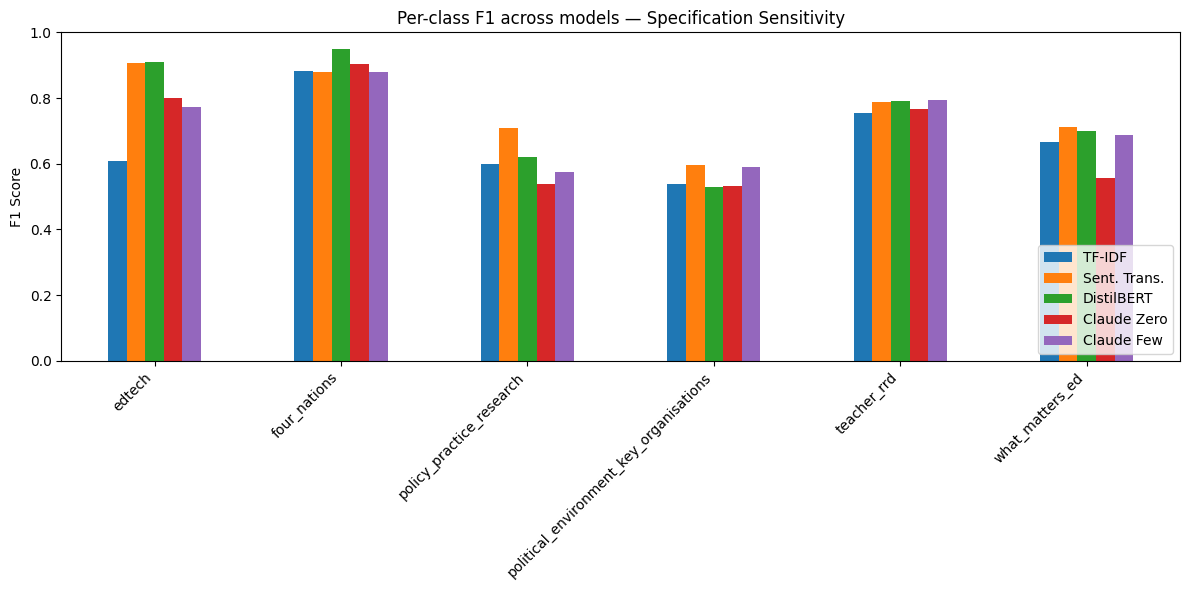

In [12]:
# Visualise per-class F1 across models
fig, ax = plt.subplots(figsize=(12, 6))
f1_df.drop(columns=["variance", "range"]).plot(kind="bar", ax=ax)
ax.set_ylabel("F1 Score")
ax.set_title("Per-class F1 across models — Specification Sensitivity")
ax.set_xticklabels(label_names, rotation=45, ha="right")
ax.legend(loc="lower right")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

### Specification Sensitivity

**`edtech` is the most model-sensitive category** (variance 0.015, range 0.30). TF-IDF scores 0.61 while sentence transformer scores 0.91 — the choice of model matters enormously here. Keyword matching fails on edtech because articles mention organisations (DfE, Ofsted) that pull predictions elsewhere; semantic models fix this.

**`teacher_rrd` is the least sensitive** (variance 0.0003, range 0.04). Every model scores 0.75–0.79. The vocabulary is so distinctive ("teacher", "recruitment", "retention") that even TF-IDF handles it well. Model choice barely matters.

**`political_environment` is consistently weak across all models** (0.53–0.60). No model cracks 0.60 F1. This isn't a specification sensitivity finding — it's a category definition problem. The specification choice doesn't help because the category itself is too broad.

**Key insight:** specification sensitivity is highest where the problem requires semantic understanding (edtech) and lowest where keyword matching is sufficient (teacher_rrd). The overlapping triangle categories (political_environment, policy_practice_research, what_matters_ed) have moderate sensitivity but are consistently weak — changing the model helps a bit but doesn't fix the underlying category overlap.

# 3. False positive analysis — Sentence Transformer (best model)

In [14]:
for cls in label_names:
    fps = [(i, sbert_pred[i], y_val.iloc[i]) 
           for i in range(len(y_val)) 
           if sbert_pred[i] == cls and y_val.iloc[i] != cls]
    if fps:
        print(f"\n--- False positives for {cls} ({len(fps)}) ---\n")
        for idx, pred, actual in fps:
            conf = sbert_proba[idx][np.where(sbert_classes == cls)[0][0]]
            print(f"  Predicted: {cls} ({conf:.2f})")
            print(f"  Actual:    {actual}")
            print(f"  Text:      {val_df.iloc[idx]['text_clean'][:150]}")
            print()


--- False positives for edtech (3) ---

  Predicted: edtech (0.28)
  Actual:    teacher_rrd
  Text:      DfE Press release - Red tape slashed to get more teachers into classrooms Government announces cuts to the duration of school-based apprenticeships to

  Predicted: edtech (0.51)
  Actual:    policy_practice_research
  Text:      NEW INQUIRY: Lords Communications and Digital Committee - Large language models How this tech is likely to evolve in the next few years and whether re

  Predicted: edtech (0.67)
  Actual:    political_environment_key_organisations
  Text:      DfE - Young people to benefit from creative education boost New package announced to support young people to access high-quality arts education and en


--- False positives for four_nations (1) ---

  Predicted: four_nations (0.67)
  Actual:    political_environment_key_organisations
  Text:      The Scottish government has announced its 2023-24 Programme for Government, This will see the creation of an educational 

### False positive analysis — Sentence Transformer

**41 total false positives.** Key patterns:

**`political_environment` (11 FPs) and `teacher_rrd` (11 FPs) are the biggest offenders** — they pull in articles from other categories. `teacher_rrd` triggers on any mention of teachers regardless of focus: "DfE tells trainers" (0.84 confidence) and "teacher training reforms review" (0.60) are both about DfE actions, not teacher workforce issues.

**`political_environment` absorbs everything government-related** — SEND inquiries, devolution bills, Sure Start research, Children's Commissioner. If a government body is mentioned, the model leans towards this category.

**Confidence is generally low on false positives** — most are 0.30–0.50. Good for the hybrid approach: these are exactly the articles that would be routed to Claude at a 0.40 threshold.

**`teacher_rrd` has the lowest specification sensitivity variance** (0.0003) **but this masks a consistent precision problem** — all models trigger on "teacher" mentions regardless of whether the article is about the teaching workforce. Low variance doesn't mean the category is well-handled, it means all models share the same bias. Stable F1 hides the fact that high recall compensates for poor precision.

**Why the sentence transformer has the same bias as TF-IDF:** "policy affecting teachers" and "teacher workforce issues" are semantically almost identical — both are about teachers in education. The difference is editorial intent: who is acting (DfE vs schools) and which newsletter section the curator wants it in. No embedding model can separate these because the meanings genuinely overlap. Claude does better on top-2 because it can reason about editorial intent, not just semantic similarity.

**What this tells us about specification sensitivity:** low variance across model specifications can mean two things — either all models handle the category well (genuine robustness), or all models share the same systematic bias (hidden fragility). You can't distinguish these from the variance table alone — you need false positive analysis to check. This is a methodological finding for the SST framework: specification sensitivity metrics must be paired with error analysis to avoid false confidence in low-variance categories.

# 4. Calibration comparison

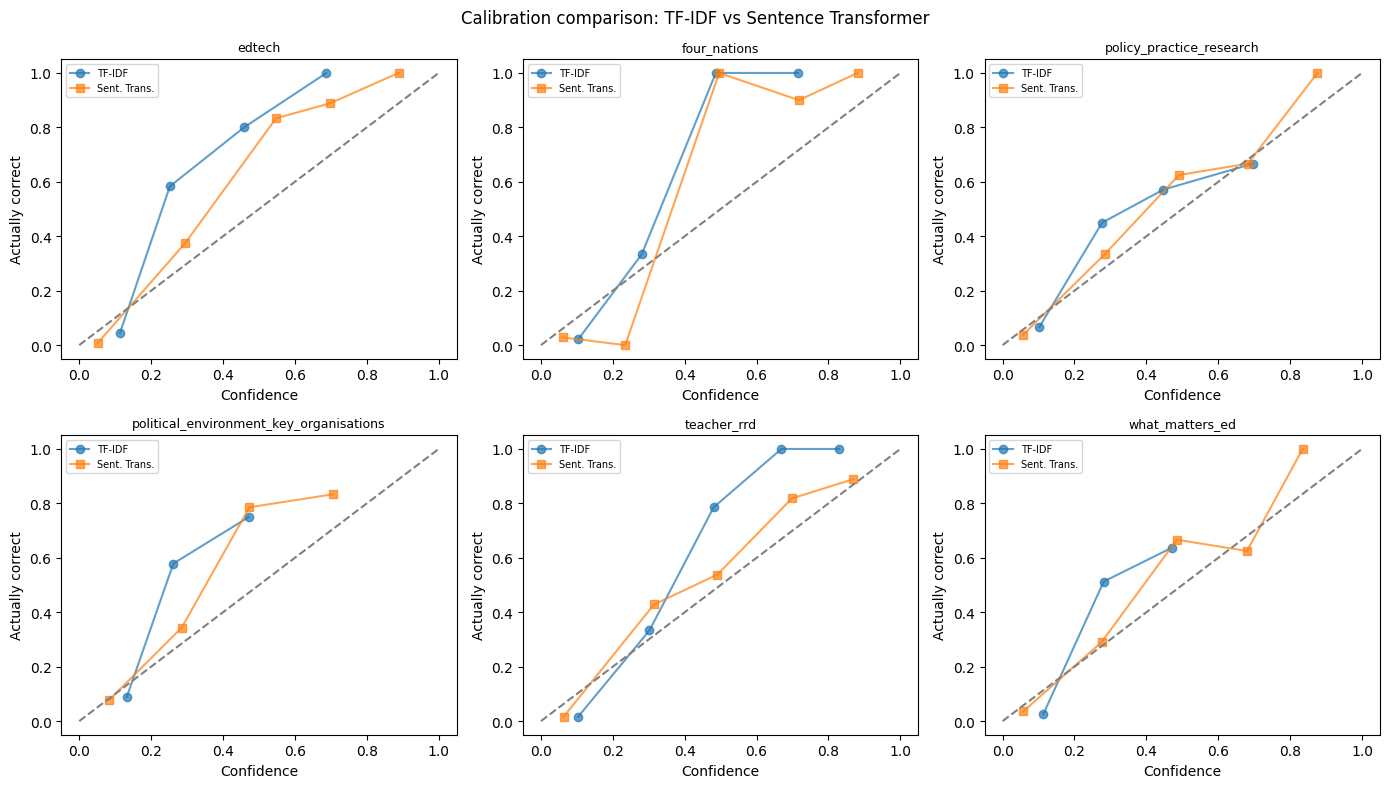

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, cls in enumerate(label_names):
    mask = (y_val == cls).astype(int)
    cls_idx_tfidf = np.where(tfidf_clf.classes_ == cls)[0][0]
    cls_idx_sbert = np.where(sbert_classes == cls)[0][0]
    
    # TF-IDF
    pt, pp = calibration_curve(mask, tfidf_proba[:, cls_idx_tfidf], n_bins=5, strategy="uniform")
    axes[i].plot(pp, pt, marker="o", label="TF-IDF", alpha=0.7)
    
    # Sentence Transformer
    pt, pp = calibration_curve(mask, sbert_proba[:, cls_idx_sbert], n_bins=5, strategy="uniform")
    axes[i].plot(pp, pt, marker="s", label="Sent. Trans.", alpha=0.7)
    
    axes[i].plot([0, 1], [0, 1], "--", color="grey")
    axes[i].set_title(cls, fontsize=9)
    axes[i].set_xlabel("Confidence")
    axes[i].set_ylabel("Actually correct")
    axes[i].legend(fontsize=7)

plt.suptitle("Calibration comparison: TF-IDF vs Sentence Transformer")
plt.tight_layout()
plt.show()

### Calibration comparison

Both models are underconfident (above the diagonal) — safe for the curator. Key differences:

- **TF-IDF is more underconfident** than ST across most classes — it says 0.30 when it's right ~0.60. The ST tracks closer to the diagonal, meaning its confidence scores are more trustworthy.
- **`policy_practice_research`** and **`what_matters_ed`** — both models are well calibrated, close to the diagonal.
- **`four_nations`** — TF-IDF is much more underconfident than ST at higher confidence levels. Both reach 100% accuracy but TF-IDF reports lower confidence getting there.
- **`teacher_rrd`** — TF-IDF is more underconfident than ST. ST tracks the diagonal better.

**Conclusion:** ST has better calibrated confidence scores than TF-IDF — another reason ST is the right production choice. The curator can trust ST's confidence scores more.


# 5. Label Consistency Check 


In [16]:
# Check if similar articles got different labels
from sklearn.metrics.pairwise import cosine_similarity

# Find pairs with high embedding similarity but different labels
sbert_emb_train = np.load(MODEL_DIR / "sbert_train_embeddings.npy")
sim_matrix = cosine_similarity(sbert_emb_train)

# Find highly similar articles with different labels
train_df_full = pd.read_csv(DATA_DIR / "train.csv")
for i in range(len(train_df_full)):
    for j in range(i+1, len(train_df_full)):
        if sim_matrix[i][j] > 0.85 and train_df_full.iloc[i]["target"] != train_df_full.iloc[j]["target"]:
            print(f"Similarity: {sim_matrix[i][j]:.3f}")
            print(f"  A: [{train_df_full.iloc[i]['target']}] {train_df_full.iloc[i]['text_clean'][:120]}")
            print(f"  B: [{train_df_full.iloc[j]['target']}] {train_df_full.iloc[j]['text_clean'][:120]}")
            print()


Similarity: 0.884
  A: [teacher_rrd] CCT Working paper - Revisiting the notion of teacher professionalism Dr Lisa-Maria Müller & Dr Victoria Cook
  B: [policy_practice_research] Chartered College of Teaching - Revisiting the notion of teacher professionalism - A working paper Dr Lisa-Maria Müller 



# Interpretation 

**Label consistency check — ground truth disagrees with itself**
* motivated by the finding that all five models struggled on the same ~11 articles and that calibration curves showed both models were more accurate than labels suggested.
* If models consistently "get it wrong" on the same articles, maybe the labels are wrong, not the models.
* Found semantically near-identical articles with different labels in the training data: "Revisiting the notion of teacher professionalism" (Müller & Cook) was labelled `teacher_rrd` in one newsletter and `policy_practice_research` in another (cosine similarity 0.884). Same paper, same curator, different label.
* This confirms the ~7% model miss rate includes cases where the ground truth itself is inconsistent.
* The model's ceiling is bounded by human labelling consistency, not just model capacity.
  
**Limitation:** inter-annotator agreement testing was not possible as only one curator labels the newsletter. If a second annotator were available, measuring agreement would establish the human ceiling that any model should be compared against — recommended for future work.


# 6. Top-2 per-class comparison across all models

In [17]:
# Top-2 per-class accuracy for each model
top2_per_class = {}

# TF-IDF
tfidf_top2 = {}
for cls in label_names:
    mask = y_val == cls
    top2_preds = np.argsort(tfidf_proba[mask], axis=1)[:, -2:]
    cls_idx = np.where(tfidf_clf.classes_ == cls)[0][0]
    tfidf_top2[cls] = np.mean([cls_idx in row for row in top2_preds])
top2_per_class["TF-IDF"] = tfidf_top2

# Sentence Transformer
sbert_top2 = {}
for cls in label_names:
    mask = y_val == cls
    top2_preds = np.argsort(sbert_proba[mask], axis=1)[:, -2:]
    cls_idx = np.where(sbert_classes == cls)[0][0]
    sbert_top2[cls] = np.mean([cls_idx in row for row in top2_preds])
top2_per_class["Sent. Trans."] = sbert_top2

# DistilBERT — hardcoded from notebook 05
top2_per_class["DistilBERT"] = {
    "edtech": 0.96, "four_nations": 0.95, "policy_practice_research": 0.67,
    "political_environment_key_organisations": 0.89, "teacher_rrd": 0.93, "what_matters_ed": 0.90,
}

# Claude Zero-Shot
claude_zero_top2 = {}
for cls in label_names:
    mask = valid_zero["true_label"] == cls
    hits = ((valid_zero.loc[mask, "category"] == cls) | (valid_zero.loc[mask, "second_category"] == cls))
    claude_zero_top2[cls] = hits.mean()
top2_per_class["Claude Zero"] = claude_zero_top2

# Claude Few-Shot
claude_few_top2 = {}
for cls in label_names:
    mask = valid_few["true_label"] == cls
    hits = ((valid_few.loc[mask, "category"] == cls) | (valid_few.loc[mask, "second_category"] == cls))
    claude_few_top2[cls] = hits.mean()
top2_per_class["Claude Few"] = claude_few_top2

# Display
top2_df = pd.DataFrame(top2_per_class)
top2_df["variance"] = top2_df.var(axis=1)
print("Top-2 per-class accuracy across all models:\n")
print(top2_df.round(3).to_string())
print(f"\nHighest variance: {top2_df['variance'].idxmax()} ({top2_df['variance'].max():.4f})")
print(f"Lowest variance:  {top2_df['variance'].idxmin()} ({top2_df['variance'].min():.4f})")

Top-2 per-class accuracy across all models:

                                         TF-IDF  Sent. Trans.  DistilBERT  Claude Zero  Claude Few  variance
edtech                                    0.885         1.000        0.96        0.962       0.962     0.002
four_nations                              0.909         0.864        0.95        1.000       1.000     0.003
policy_practice_research                  0.708         0.833        0.67        0.958       0.917     0.016
political_environment_key_organisations   0.861         0.917        0.89        0.861       0.889     0.001
teacher_rrd                               0.966         0.966        0.93        0.931       0.931     0.000
what_matters_ed                           0.900         0.900        0.90        0.897       0.933     0.000

Highest variance: policy_practice_research (0.0159)
Lowest variance:  what_matters_ed (0.0002)


### Top-2 per-class specification sensitivity

'policy_practice_research' has the highest top-2 variance because the trained models struggle to distinguish it from political_environment and what_matters_ed (the triangle), while Claude's category descriptions explicitly tell it the boundary ("the emphasis is on the research itself, not the organisation"). It's not that Claude reasons better — it's that the prompt gives it disambiguation rules the trained models have to learn from data.

`teacher_rrd` and `what_matters_ed` have near-zero variance — all models achieve 90%+ top-2 on these categories regardless of specification.

Notable: `four_nations` hits 100% top-2 with both Claude models but only 86-91% with trained models. Claude's world knowledge about UK nations gives it an edge the trained models don't have.

Overall the top-2 variance is much smaller than top-1 variance — showing top-2 suggestions are more robust to model choice than single predictions. Another justification for the top-2 approach in the pipeline.


# 7. Proxy Concentration Analysis

Are the top TF-IDF features genuinely measuring the construct (the policy category) or are they proxies — source names, geographies, author names?

In [20]:
# Proxy terms are category-specific, not global
# A term is a proxy if it correlates with the class but doesn't measure what the class is about
PROXY_TERMS_BY_CLASS = {
    "edtech": {"schoolsweek", "bbc", "guardian", "tes"},
    "four_nations": {"belfast telegraph", "telegraph"},  # geographic terms ARE the construct here
    "policy_practice_research": {"schoolsweek", "bbc", "guardian"},
    "political_environment_key_organisations": {"schoolsweek", "schools week", "bbc", "guardian", "tes", "telegraph"},
    "teacher_rrd": {"schoolsweek", "bbc", "guardian", "tes"},
    "what_matters_ed": {"schoolsweek", "bbc", "fft", "guardian", "england"},
}

feature_names = tfidf_vec.get_feature_names_out().tolist()
TOP_N = 10

for i, cls in enumerate(tfidf_clf.classes_):
    coefs = tfidf_clf.coef_[i]
    top_idx = np.argsort(coefs)[-TOP_N:][::-1]
    proxy_terms = PROXY_TERMS_BY_CLASS.get(cls, set())
    
    print(f"\n--- {cls} ---")
    for j in top_idx:
        feat = feature_names[j]
        is_proxy = "PROXY" if feat.lower() in proxy_terms else "construct"
        print(f"  {coefs[j]:+.3f}  {feat:<30s}  [{is_proxy}]")
    
    n_proxy = sum(1 for j in top_idx if feature_names[j].lower() in proxy_terms)
    print(f"  → {n_proxy}/{TOP_N} proxy features")



--- edtech ---
  +3.236  digital                         [construct]
  +1.865  use                             [construct]
  +1.864  edtech                          [construct]
  +1.347  online                          [construct]
  +1.321  generative                      [construct]
  +1.272  artificial                      [construct]
  +1.249  intelligence                    [construct]
  +1.189  tech                            [construct]
  +1.047  artificial intelligence         [construct]
  +1.003  ban                             [construct]
  → 0/10 proxy features

--- four_nations ---
  +2.800  scottish                        [construct]
  +2.518  wales                           [construct]
  +2.386  welsh                           [construct]
  +2.279  scotland                        [construct]
  +1.961  welsh government                [construct]
  +1.841  scottish government             [construct]
  +1.822  belfast                         [construct]
  +1.720  belfast te

### Proxy concentration analysis

| Category | Proxy features | Assessment |
|----------|---------------|------------|
| `edtech` | 0/10 | Clean — genuine topic terms |
| `four_nations` | 2/10 | Mostly clean — geographic terms are construct. "Belfast telegraph" and "telegraph" are source names |
| `policy_practice_research` | 0/10 | Clean — "research", "policy", "universities" |
| `political_environment` | 1/10 | Low — "schoolsweek" is a source name |
| `teacher_rrd` | 0/10 | Clean — "teacher", "recruitment", "retention" |
| `what_matters_ed` | 2/10 | Low — "england" is geographic, "fft" (FFT Education Datalab) is an organisation name |

**Overall: the TF-IDF model is mostly construct-driven.** 5 proxy features across 60 top features (8.3%). Proxies are source/organisation names ("schoolsweek", "belfast telegraph", "fft") and one geographic term ("england"). The model is largely classifying by topic content, not shortcuts.

**Key methodological point:** proxy classification must be category-specific. "Wales" is a construct term in `four_nations` (the category is about geographic focus) but would be a proxy in `political_environment` (the category is about organisational actions). A flat proxy list misclassifies legitimate features — the audit must consider what each category is supposed to measure.

**Specification sensitivity insight:** the proxy concentration is low (8.3%) which partly explains why TF-IDF performed reasonably well (0.675 macro F1) despite being the simplest model. The categories have distinctive enough vocabulary that keyword matching works — the model doesn't need to rely on shortcuts because the construct terms are strong signals. This also explains why the specification sensitivity variance for most classes is low: if all models are using the same genuine construct terms, changing the model doesn't change much. The exception is `edtech` (highest variance) — not because of proxies, but because keywords like "digital" and "AI" appear across categories, requiring semantic understanding to disambiguate.

# 8. Normative Divergence — Claude vs Sentence Transformer

Where Claude zero-shot and the Sentence Transformer disagree systematically, which direction does the disagreement go? Is Claude over-predicting certain categories? This reveals different normative assumptions about what the categories mean.

In [23]:
# Disagreement matrix: where Claude zero-shot and Sentence Transformer disagree
# For each article where they disagree, which direction?

claude_preds = valid_zero["category"].values
# Align indices — use only valid Claude predictions
sbert_preds_aligned = sbert_pred[:len(claude_preds)]

disagree_mask = claude_preds != sbert_preds_aligned
n_disagree = disagree_mask.sum()
n_agree = (~disagree_mask).sum()

print(f"Agreement: {n_agree}/{len(claude_preds)} ({n_agree/len(claude_preds):.0%})")
print(f"Disagreement: {n_disagree}/{len(claude_preds)} ({n_disagree/len(claude_preds):.0%})")

# Build disagreement matrix: rows = ST prediction, cols = Claude prediction
print(f"\nDisagreement direction (ST → Claude):\n")
disagree_df = pd.DataFrame({
    "st_pred": sbert_preds_aligned[disagree_mask],
    "claude_pred": claude_preds[disagree_mask],
})

# Cross-tabulation
crosstab = pd.crosstab(disagree_df["st_pred"], disagree_df["claude_pred"], margins=True)
print(crosstab.to_string())

# Net flow per category: how many more times does Claude predict it vs ST?
print(f"\nNet flow (Claude minus ST) per category:")
for cls in label_names:
    claude_count = (claude_preds == cls).sum()
    st_count = (sbert_preds_aligned == cls).sum()
    diff = claude_count - st_count
    direction = "Claude predicts MORE" if diff > 0 else "ST predicts MORE" if diff < 0 else "Equal"
    print(f"  {cls:45s} {diff:+3d}  ({direction})")

Agreement: 58/166 (35%)
Disagreement: 108/166 (65%)

Disagreement direction (ST → Claude):

claude_pred                              edtech  four_nations  policy_practice_research  political_environment_key_organisations  teacher_rrd  what_matters_ed  All
st_pred                                                                                                                                                            
edtech                                        0             0                         8                                        2            5                3   18
four_nations                                  2             0                         6                                        2            2                2   14
policy_practice_research                      3             2                         0                                        3            4                2   14
political_environment_key_organisations       2             3                         2 

### Normative divergence

**65% disagreement** — Claude and ST disagree on nearly two thirds of articles. They're using fundamentally different classification logic.

**The direction is systematic, not random:**
- **Claude over-predicts `policy_practice_research` by +19** — Claude sees "report", "study", "evidence" and calls it research. The ST distributes these across other categories based on topic.
- **ST over-predicts `edtech` by +8** and `teacher_rrd` by +6 — the ST triggers on topic keywords ("digital", "teacher") while Claude looks at the broader context.

**What this means:** the two models encode different assumptions about what the categories mean. The ST classifies by **topic vocabulary** (what words appear). Claude classifies by **document type** (what kind of thing is this). Neither is wrong — they're answering different questions. This is normative divergence: the specification choice (trained model vs LLM) doesn't just change accuracy, it changes *what the model treats as the authoritative definition of each category*.

**For the SST paper:** the disagreement isn't noise, it's structurally patterned. The +19 net flow to `policy_practice_research` from Claude is consistent across articles — it's a systematic specification effect, not random variation.


In [26]:
print(f"{'':.<35} {'ST + LogReg':>15} {'Claude Few-Shot':>18} {'Hybrid':>12}")
print(f"{'-'*80}")
print(f"{'Macro F1':.<35} {'0.765':>15} {'0.717':>18} {'0.760':>12}")
print(f"{'Top-2 accuracy':.<35} {'91.6%':>15} {'93.4%':>18} {'92.2%':>12}")
print(f"{'Latency per article':.<35} {'~50ms':>15} {'~1-2s':>18} {'Mixed':>12}")
print(f"{'Cost per article':.<35} {'Free':>15} {'~$0.01':>18} {'~$0.003':>12}")
print(f"{'Cost per year (15/week)':.<35} {'$0':>15} {'~$8':>18} {'~$2-3':>12}")
print(f"{'Works offline':.<35} {'Yes':>15} {'No':>18} {'Partial':>12}")
print(f"{'Updating categories':.<35} {'Retrain':>15} {'Edit prompt':>18} {'Both':>12}")
print(f"{'Calibration':.<35} {'Underconfident':>15} {'Self-reported':>18} {'Mixed':>12}")
print(f"{'Consistency':.<35} {'Deterministic':>15} {'May vary':>18} {'Mixed':>12}")

...................................     ST + LogReg    Claude Few-Shot       Hybrid
--------------------------------------------------------------------------------
Macro F1...........................           0.765              0.717        0.760
Top-2 accuracy.....................           91.6%              93.4%        92.2%
Latency per article................           ~50ms              ~1-2s        Mixed
Cost per article...................            Free             ~$0.01      ~$0.003
Cost per year (15/week)............              $0                ~$8        ~$2-3
Works offline......................             Yes                 No      Partial
Updating categories................         Retrain        Edit prompt         Both
Calibration........................  Underconfident      Self-reported        Mixed
Consistency........................   Deterministic           May vary        Mixed


#### ST wins on engineering properties (free, fast, offline, deterministic, calibrated). Claude wins on top-2 (93.4% vs 91.6%). For 15 articles/week the cost and latency differences are negligible — the real differentiators are offline capability, consistency, and how easy it is to update categories.


# 9. Frame Sensitivity — DSPy vs Hand-crafted Prompt

Three prompt specifications on the same model (Claude) produced different results. This demonstrates that the prompt is a consequential engineering choice — a frame-level specification that changes the output.

In [25]:
# Load DSPy predictions
dspy_df = pd.read_csv(DATA_DIR / "claude_dspy_predictions.csv")
valid_dspy = dspy_df[dspy_df["category"].isin(label_names)]

# Per-class F1 comparison: zero-shot vs few-shot vs DSPy
frame_comparison = pd.DataFrame({
    "Zero-shot": f1_per_class(valid_zero["true_label"], valid_zero["category"], average=None, labels=label_names),
    "Few-shot": f1_per_class(valid_few["true_label"], valid_few["category"], average=None, labels=label_names),
    "DSPy": f1_per_class(valid_dspy["true_label"], valid_dspy["category"], average=None, labels=label_names),
}, index=label_names)

frame_comparison["range"] = frame_comparison.max(axis=1) - frame_comparison.min(axis=1)

print("Frame Sensitivity: per-class F1 across three prompt specifications\n")
print(frame_comparison.round(3).to_string())

print(f"\nMacro F1:")
print(f"  Zero-shot:  {f1_score(valid_zero['true_label'], valid_zero['category'], average='macro'):.3f}")
print(f"  Few-shot:   {f1_score(valid_few['true_label'], valid_few['category'], average='macro'):.3f}")
print(f"  DSPy:       {f1_score(valid_dspy['true_label'], valid_dspy['category'], average='macro'):.3f}")

print(f"\nHighest frame sensitivity: {frame_comparison['range'].idxmax()} (range: {frame_comparison['range'].max():.3f})")
print(f"Lowest frame sensitivity:  {frame_comparison['range'].idxmin()} (range: {frame_comparison['range'].min():.3f})")

Frame Sensitivity: per-class F1 across three prompt specifications

                                         Zero-shot  Few-shot   DSPy  range
edtech                                       0.800     0.773  0.920  0.147
four_nations                                 0.905     0.878  0.821  0.084
policy_practice_research                     0.537     0.576  0.513  0.063
political_environment_key_organisations      0.531     0.592  0.516  0.075
teacher_rrd                                  0.767     0.793  0.627  0.166
what_matters_ed                              0.556     0.689  0.407  0.281

Macro F1:
  Zero-shot:  0.683
  Few-shot:   0.717
  DSPy:       0.634

Highest frame sensitivity: what_matters_ed (range: 0.281)
Lowest frame sensitivity:  policy_practice_research (range: 0.063)


#### Frame sensitivity

Three prompt specifications on the same model (Claude) produce meaningfully different results (0.634–0.717 macro F1).

**`what_matters_ed` is the most frame-sensitive** (range 0.281) — few-shot scores 0.689 but DSPy drops to 0.407. DSPy rewrote this category as "curriculum, assessment, student outcomes" instead of the curator's actual focus (SEND, poverty, mental health). The description wording directly determines what gets classified here.

**`policy_practice_research` is the least frame-sensitive** (range 0.063) — all three prompts struggle equally (0.51–0.58). This category is genuinely hard to define regardless of wording.

**`teacher_rrd`** shows a surprising range (0.166) — DSPy dropped to 0.627 because it only included 2 teacher examples vs the few-shot's balanced 2-per-class. Missing examples hurt more than missing descriptions.

**Key finding:** prompt wording changes outcomes more for categories with ambiguous definitions (`what_matters_ed`) than for categories with clear boundaries (`policy_practice_research` is consistently weak, `four_nations` is consistently strong). Frame sensitivity is highest where the construct is least well-defined — the prompt fills in the gaps differently each time.

# Summary & Conclusions

## Final comparison

| Model | Macro F1 | Top-2 | Best for |
|-------|----------|-------|----------|
| TF-IDF + LogReg | 0.675 | 87.4% | Baseline reference |
| Sentence Transformer + metadata | **0.765** | 91.6% | **Final model** — best top-1, calibrated, offline, deterministic |
| Fine-tuned DistilBERT | 0.750 | 88.6% | Not recommended — overconfident, slow to train |
| Claude Zero-Shot | 0.683 | 92.8% | No training needed |
| Claude Few-Shot | 0.717 | **93.4%** | Best top-2, validation benchmark |

## Specification sensitivity findings

- **`edtech`** is the most model-sensitive category (range 0.30) — keyword matching fails, semantic models fix it
- **`teacher_rrd`** has lowest variance but masks a consistent precision problem — all models share the same proxy bias
- **`political_environment`** is consistently weak (0.53–0.60) — category definition problem, not model problem
- **Prompt wording is a consequential specification choice** (zero-shot 0.683, few-shot 0.717, DSPy 0.634) — `what_matters_ed` is most frame-sensitive (range 0.281)
- **Normative divergence:** Claude and ST disagree on 65% of articles with systematic directional bias (+19 to `policy_practice_research` from Claude)
- **Proxy concentration is low** (8.3%) — specification sensitivity comes from model architecture, not feature shortcuts
- **Ground truth is inconsistent** — same article labelled differently by the same curator in different newsletters. Model ceiling is bounded by human labelling consistency
- **Top-2 is more robust to model choice** than top-1 — per-class variance is near-zero, curator experience is consistent regardless of model

## Final model decision

**Sentence Transformer + metadata.** Best top-1 (0.765), runs locally, deterministic, no cost, calibrated confidence scores. The 2% top-2 gap vs Claude is ~3 articles per year. Claude serves as validation benchmark proving the trained model matches LLM-level performance.
